In [1]:
import sys
import os

#print(sys.modules)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import esmpy as E

workdir_ = '../'  #'/glade/work/juliob'
if ( workdir_ not in sys.path ):
    sys.path.append(workdir_)
    print( f" a path to {workdir_} added in {__name__} ")



from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import MyConstants as Con
from Regridder import ReadInSrc as Rd
from Regridder import WriteDST as Wrt
from Regridder import Initialize as Ini
from Regridder import GenRegrid as GnR
# This contains all the data
#----------------------------
from Regridder import GlobalVarClass
from Regridder.GlobalVarClass import Gv
from Regridder import VertRegridFlexLL as vrg

import importlib

# Reload likely modules during development
importlib.reload(GrU)
importlib.reload(MkP)
importlib.reload(Rd)
importlib.reload(Wrt)
importlib.reload(Ini)
importlib.reload(GnR)
importlib.reload(vrg)


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/ReanalysisRegrid_dev/Drivers/Utils 
 Utils.MyConstants in /glade/work/juliob/ReanalysisRegrid_dev/Drivers/Utils 
from inside GenRegrid.py
['/glade/u/apps/opt/conda/envs/npl-2025a/lib/python312.zip', '/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12', '/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/lib-dynload', '', '/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages', '../']
 Utils.MyConstants in /glade/work/juliob/ReanalysisRegrid_dev/Drivers/Utils 
 Utils.MyConstants in /glade/work/juliob/ReanalysisRegrid_dev/Drivers/Utils 
from inside GenRegrid.py
['/glade/u/apps/opt/conda/envs/npl-2025a/lib/python312.zip', '/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12', '/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/lib-dynload', '', '/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages', '../']
 Utils.MyConstants in /glade/work/juliob/ReanalysisRegrid_dev/Drivers/

<module 'Regridder.VertRegridFlexLL' from '/glade/work/juliob/ReanalysisRegrid_dev/Drivers/Diagnostics/../Regridder/VertRegridFlexLL.py'>

In [2]:
rc = Ini.prep(Dst = 'mpasa120', DstVgrid='L58_mpas',  Src='ERA5', WOsrf=False , RegridMethod="CONSERVE", IC_for_pg=False, mpas_nudging=True )


In prep Src= ERA5 to Dst=mpasa120 
Used NEW, concise gridInfo function .... ....
Generating regridding weights. Method CONSERVE : ESMF method= 2
 Src scripfile /glade/work/juliob/ERA5-proc/ERA5interp/grids/ERA5_640x1280_scrip.nc 
 Dst scripfile /glade/campaign/cesm/cesmdata/cseg/inputdata/share/scripgrids/mpasa120_SCRIP_desc_211008.nc 
 Src topo file /glade/work/juliob/ERA5-proc/ERA5interp/phis/ERA5_phis.nc 
 Dst topo file /glade/campaign/cesm/cesmdata/cseg/inputdata/atm/cam/topo/mpas/mpasa120_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_20240507.nc 
 L58_mpas Dst vertical grid from /glade/campaign/cesm/cesmdata/cseg/inputdata//atm/cam/inic/mpas/cami_01-01-2000_00Z_mpasa120_L58_CFSR_c240814.nc 
Prepping for ERA5 to mpasa120 proc in Regridder.Initialize took  23.0195 seconds


In [3]:
%%time
year,month,day,hour=2002,1,1,0
rc = Rd.get_Src( year=year ,month=month ,day=day , hour0=hour )

Time tags for ERA5 files ...
200201
2002010100_2002010105
tzc
Serial read of data 
['/glade/campaign/collections/rda/data/d633006/e5.oper.an.ml/200201/e5.oper.an.ml.128_134_sp.regn320sc.2002010100_2002010105.nc', '/glade/campaign/collections/rda/data/d633006/e5.oper.an.ml/200201/e5.oper.an.ml.0_5_0_0_0_t.regn320sc.2002010100_2002010105.nc', '/glade/campaign/collections/rda/data/d633006/e5.oper.an.ml/200201/e5.oper.an.ml.0_5_0_1_0_q.regn320sc.2002010100_2002010105.nc', '/glade/campaign/collections/rda/data/d633006/e5.oper.an.ml/200201/e5.oper.an.ml.0_5_0_2_2_u.regn320uv.2002010100_2002010105.nc', '/glade/campaign/collections/rda/data/d633006/e5.oper.an.ml/200201/e5.oper.an.ml.0_5_0_2_3_v.regn320uv.2002010100_2002010105.nc', '/glade/campaign/collections/rda/data/d633006/e5.oper.an.ml/200201/e5.oper.an.ml.0_5_0_2_8_w.regn320sc.2002010100_2002010105.nc']
Reading data vars for 2002010100_2002010105 took  1.4918 seconds
Extracting values from Xarrays took 14.1662 seconds
ERA5 Global mean sur

In [4]:
rc = GnR.xRegrid_mpas_phys( ExitAfterTemperature=False , 
             HorzInterpLnPs=False , 
             Use_ps_ERA_xCAM_in_vert=True )

starting xRegrid_mpas_phys ERA5 _x_ mpasa120 at Tue Apr  8 13:23:42 2025 
 .. size of tiled Gv.zgrid_CAM (1, 59, 40962)
Finished phis Horz Rgrd  1.3246 seconds
Finished ps Horz Rgrd  1.3274 seconds
Finished z3o Horz Rgrd  1.7616 seconds
Finished TE Horz Rgrd  2.0988 seconds
 going into vertical regrid of T 
Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 3.1588 seconds
Finished TE Vert Rgrd  5.2581 seconds
Fill method lapse_extrapolate
 ... Bottom filling took 0.0808 seconds
Finished TE bottom fill 5.3389 seconds
 going into horz+vertical regrid of Q 
Horz RG in fullRegrid 
Vert RG in fullRegrid 
Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 0.8908 seconds
Fill method lapse_extrapolate
 ... Bottom filling took 0.0794 seconds
 Digressing to make CAM pressures 
Finished making pressures for CAM 6.7063 seconds
 Saturating

In [ ]:
#rc=Wrt.write_netcdf_mpas_nudging()

In [ ]:
print(Gv.pdTime_ERA)

In [6]:
#-----------------------------------------
# Calculate difference between phis's
#-----------------------------------------
Dphis = ( Gv.phis_ERA_xCAM - Gv.phis_CAM )/ Con.grav()
Dps= Gv.ps_ERA_xCAM - Gv.ps_CAM 

CAM_subt_oo = np.where( Dphis>500. )

CAM_supert_oo = np.where( Dphis<500. )

print( np.shape(Dps))
print( np.shape(Dphis))


(1, 40962)
(40962,)


In [ ]:
c0,c1=12_600,12_800
c0,c1=32_600,32_800

fig, ax = plt.subplots(1,2, figsize=(20, 8))
ax=ax.flatten()
ax[0].plot( Gv.phis_ERA_xCAM[c0:c1]/Con.grav() )
ax[0].plot( Gv.phis_CAM[c0:c1]/Con.grav() )

ax[1].plot( Gv.ps_ERA_xCAM[0,c0:c1]/Con.grav() )
ax[1].plot( Gv.ps_CAM[0,c0:c1]/Con.grav() )


In [ ]:
plt.scatter( Dphis, Dps[0,:] )



In [ ]:
plt.plot( Dphis[ CAM_supert_oo[0] ] )
#plt.xlim( 80,100)
plt.xlim( 12590,12600)

26850


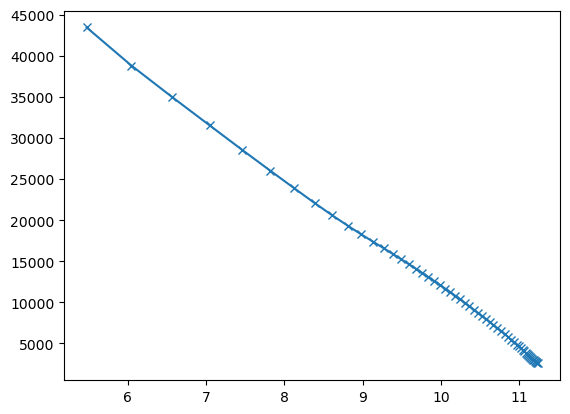

In [10]:
icol=CAM_subt_oo[0][83]
print(icol)
#icol=CAM_supert_oo[0][12_595]

#plt.plot(  Gv.v_ERA_xzCAM[0,:,icol] , Gv.zgrido_CAM[0,:,icol],'-o')
#plt.plot(  Gv.v_ERA_xCAM[0,:,icol] , Gv.z3o_ERA_xCAM[0,:,icol],'-x')

#plt.plot(  Gv.v_ERA_xzCAM[0,:,icol] , Gv.zgrido_CAM[0,:,icol],'-o')
plt.plot(  np.log(Gv.pmid_CAM[0,:,icol]) , Gv.zgrido_CAM[0,:,icol],'-x')

#plt.ylim( 2000,4000 )
#plt.ylim( 0,10000)

In [ ]:
plt.plot( (Gv.phis_ERA_xCAM - Gv.phis_CAM )/Con.grav() )

In [ ]:
zoo = np.sum( Gv.area_CAM * Gv.zgrid_CAM[0,:,:], axis=1 )/np.sum( Gv.area_CAM , axis=0 )
plt.plot(zoo)

In [ ]:
poo=xr.open_dataset('/glade/campaign/cesm/cesmdata/cseg/inputdata/atm/cam/inic/mpas/FC2000climo_mpasa120.cam.i.0006-01-01_c211207.nc')
#poo.areaCell
plt.plot(Gv.area_CAM)


In [ ]:
print( np.shape(Gv.lon_CAM))
print( np.shape(Gv.phis_ERA_xCAM))
#plt.plot( Gv.phis_CAM /Con.grav() )
plt.plot( (Gv.phis_ERA_xCAM - Gv.phis_CAM )/Con.grav() )


In [ ]:
fig, ax = plt.subplots(1,2, figsize=(20, 8))

# Flatten axs to easily access each subplot by index
ax = ax.flatten()
ax[0].tricontourf( Gv.lon_CAM, Gv.lat_CAM, Gv.phis_ERA_xCAM )
ax[1].tricontourf( Gv.lon_CAM, Gv.lat_CAM, Gv.phis_CAM )



In [ ]:
 
Gv.pmid_ERA, Gv.pint_ERA, Gv.delp_ERA = MkP.Pressure (
                    am=Gv.amid_ERA ,
                    bm=Gv.bmid_ERA ,
                    ai=Gv.aint_ERA ,
                    bi=Gv.bint_ERA ,
                    ps=Gv.ps_ERA ,
                    p_00=Gv.p_00_ERA ,
                    Gridkey = Gv.srcTZHkey )


In [ ]:
plt.plot( Gv.phis_ERA.flatten() )

In [ ]:
topo=Gv.phis_ERA/Con.grav()
topo_x = np.tile( topo, (6,1) ).reshape( 6, 640,1280 )
print(np.shape(topo))
print(np.shape(topo_x))
#plt.contour( topo ,levels=(1,10,1000) )
plt.contour( topo_x[0,:,:] ,levels=(1,10,1000) )


In [ ]:
print( np.shape( Gv.pint_ERA ) )
print( np.shape( Gv.te_ERA ) )


In [ ]:
%%time

z3e,z3o,delz = MkP.GeopHeight( te=Gv.te_ERA , pint=Gv.pint_ERA , pmid=Gv.pmid_ERA , qv=None, topo=topo , Gridkey='tzyx')


In [ ]:
%%time

z3ev,z3ov,delzv = MkP.GeopHeight( te=Gv.te_ERA , pint=Gv.pint_ERA ,  pmid=Gv.pmid_ERA , qv=Gv.q_ERA , topo=topo , Gridkey='tzyx')


In [ ]:
print( np.min(Gv.q_ERA))

In [ ]:
dz3e=z3ev[0,1,300,:] -z3e[0,1,300,:]
#plt.plot( Gv.te_ERA[0,0,300,:].flatten() ) 
plt.plot( z3o[0,:,300,600] , 'o')
plt.plot( z3ov[0,:,300,600] , 'x')
#plt.plot( delz[0,0,300,:] )
#plt.plot( dz3e.flatten() )
#plt.plot( (z3ev-z3e)[0,:,300,600] ) 
print( delz[0,0,300,:] )

In [ ]:
plt.plot( Gv.aint_ERA / 100_000. )

In [ ]:
plt.contour( z3e[0,137,:,:] ,levels=(1,10,1000) )

In [ ]:

f='/glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/mpas/cami_01-01-2000_00Z_mpasa120_L58_CFSR_c240814.nc'


In [ ]:
X=xr.open_dataset( f )

In [ ]:
X

In [ ]:
zgrid=X.zgrid.values
lon=X.lonCell
lat=X.latCell


In [ ]:
print(zgrid.shape)

In [ ]:
plt.tricontourf( lon,lat,zgrid[:,0] )

In [ ]:
plt.